# Download and prepare data 

1. UAVSAR SLCs -> coherence rasters
    1. Download from JPL 
    2. Geolocate, calculate coherence for each image pair 
    3. Reproject and downsample to 30m 
    4. Get outline shapefile for each scene
2. Get DEM 
    1. Download using 3dep API and clip to scene extents
    2. Reproject and downsample to 30m
    3. Calculate slope, aspect, convexity
3. Calculate incidence angle
    1. Use uavsar_pytools to calculate incidence angle
4. Get other input data 




In [3]:
import numpy as np 
import os
import sys
from osgeo import gdal, ogr, osr
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

from uavsar_pytools import UavsarCollection

/bsuhome/julialober/miniforge3/envs/coherence/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
RES = 30
CRS = 'EPSG:26911'

### UAVSAR Data

- Where to find it? 
- How to download it? 
Users will be on their own for this. SLCs have to be downloaded from [JPL's UAVSAR site](https://uavsar.jpl.nasa.gov/cgi-bin/data.pl) and I can't find a good way to automate it. 
- Processing steps: 
    - Geolocation
    - Coherence calculation
    - Reprojection and downsampling
    - Temporal model fit and 12-day prediction

In [4]:
slc_dir = '../data/uavsar/slc/'

# ChatGPT wrote this function for me to get a shapefile from my tif 
# I'll move on from this later
def tif_to_shapefile(tif_path, out_shapefile):
    """
    Convert a GeoTIFF to a shapefile containing a single polygon
    that outlines all valid (non-nodata) pixels.
    """
    ds = gdal.Open(tif_path)
    if ds is None:
        raise RuntimeError(f"Failed to open: {tif_path}")

    band = ds.GetRasterBand(1)
    if band is None:
        raise RuntimeError(f"No raster band in: {tif_path}")

    arr = band.ReadAsArray()
    nodata = band.GetNoDataValue()

    # robust valid-mask (handles NaN and nodata)
    if nodata is None:
        mask = np.isfinite(arr)
    else:
        # use isclose for float nodata, and also require finite values
        mask = np.isfinite(arr) & (~np.isclose(arr, nodata))

    print("total:", arr.size, "valid:", int(mask.sum()),
      "nan:", int(np.isnan(arr).sum()),
      "==nodata:", int(np.isclose(arr, nodata).sum()) if nodata is not None else 0)

    if not mask.any():
        raise RuntimeError("No valid data found in raster.")

    # create in-memory raster of the mask
    mem_drv = gdal.GetDriverByName("MEM")
    mem = mem_drv.Create("", ds.RasterXSize, ds.RasterYSize, 1, gdal.GDT_Byte)
    mem.SetGeoTransform(ds.GetGeoTransform())
    mem.SetProjection(ds.GetProjection())
    mem_band = mem.GetRasterBand(1)
    mem_band.WriteArray(mask.astype(np.uint8))
    mem_band.FlushCache()

    # polygonize into an in-memory vector layer
    ogr_drv = ogr.GetDriverByName("Memory")
    mem_ds = ogr_drv.CreateDataSource("mem")
    srs = None
    wkt = ds.GetProjection()
    if wkt:
        srs = osr.SpatialReference()
        srs.ImportFromWkt(wkt)
    layer = mem_ds.CreateLayer("mask", srs=srs, geom_type=ogr.wkbPolygon)
    fld = ogr.FieldDefn("value", ogr.OFTInteger)
    layer.CreateField(fld)
    gdal.Polygonize(mem.GetRasterBand(1), None, layer, 0, [], callback=None)

    # union polygons where value == 1
    layer.ResetReading()
    geom_union = None
    feat = layer.GetNextFeature()
    while feat:
        if feat.GetField("value") == 1:
            g = feat.GetGeometryRef()
            if g is not None:
                g_clone = g.Clone()
                if geom_union is None:
                    geom_union = g_clone
                else:
                    geom_union = geom_union.Union(g_clone)
        feat = layer.GetNextFeature()

    if geom_union is None:
        raise RuntimeError("No polygons created from mask.")

    # ensure MultiPolygon
    if geom_union.GetGeometryType() == ogr.wkbPolygon:
        multi = ogr.Geometry(ogr.wkbMultiPolygon)
        multi.AddGeometry(geom_union)
        geom_union = multi

    # write output shapefile (overwrite if exists)
    shp_drv = ogr.GetDriverByName("ESRI Shapefile")
    if os.path.exists(out_shapefile):
        shp_drv.DeleteDataSource(out_shapefile)
    out_ds = shp_drv.CreateDataSource(out_shapefile)
    out_layer = out_ds.CreateLayer("outline", srs=srs, geom_type=ogr.wkbMultiPolygon)
    id_fd = ogr.FieldDefn("id", ogr.OFTInteger)
    out_layer.CreateField(id_fd)

    feat_def = out_layer.GetLayerDefn()
    out_feat = ogr.Feature(feat_def)
    out_feat.SetGeometry(geom_union)
    out_feat.SetField("id", 1)
    out_layer.CreateFeature(out_feat)

    out_ds.Destroy()
    mem_ds.Destroy()
    mem = None
    ds = None

    print(f"Created outline shapefile: {out_shapefile}")

In [20]:
tif_to_shapefile("../data/lowman_05208_coherence_20200131_20200213.tif",
                 "../data/lowman_05208.shp")

total: 40798368 valid: 18674692 nan: 22123676 ==nodata: 0
Created outline shapefile: ../data/lowman_05208.shp


In [6]:
tif_to_shapefile("/bsuhome/julialober/scratch/comp_transfer/snowex_uavsar_coherence/data/snowex_lowman/dem_params/MCS_aspect_5m.tif",
                 "/bsuhome/julialober/scratch/coherence_data/kmls/mores_creek.shp")

total: 2674840 valid: 1359621 nan: 1315219 ==nodata: 0
Created outline shapefile: /bsuhome/julialober/scratch/coherence_data/kmls/mores_creek.shp


In [ ]:
# tif overview function 
from osgeo import gdal
import numpy as np

def print_tif_stats(tif_path):
    ds = gdal.Open(tif_path)
    if ds is None:
        print("Failed to open:", tif_path); return
    band = ds.GetRasterBand(1)
    arr = band.ReadAsArray().astype(float)
    nodata = band.GetNoDataValue()

    total = arr.size
    nan_count = np.isnan(arr).sum()
    zero_count = np.count_nonzero(arr == 0)
    nodata_count = 0 if nodata is None else np.count_nonzero(arr == nodata)
    valid_mask = ~np.isnan(arr)
    if nodata is not None:
        valid_mask &= (arr != nodata)
    valid_count = valid_mask.sum()

    print("file:", tif_path)
    print("size (cols, rows):", ds.RasterXSize, ds.RasterYSize)
    print("projection WKT (truncated):", (ds.GetProjection() or "")[:200])
    print("geotransform:", ds.GetGeoTransform())
    print("dtype:", arr.dtype, "nodata:", nodata)
    print("total pixels:", total)
    print("valid pixels (not nan and not nodata):", valid_count, f"({valid_count/total:.2%})")
    print("nan count:", int(nan_count), f"({nan_count/total:.2%})")
    print("zero count:", int(zero_count), f"({zero_count/total:.2%})")
    if nodata is not None:
        print("nodata count:", int(nodata_count), f"({nodata_count/total:.2%})")

    # min/max of valid pixels
    if valid_count:
        vals = arr[valid_mask]
        print("valid min/max:", float(np.nanmin(vals)), "/", float(np.nanmax(vals)))
    else:
        print("no valid pixels found")

# Example:
print_tif_stats("../data/lowman_05208_coherence_20200131_20200213.tif")

file: ../data/lowman_05208_coherence_20200131_20200213.tif
size (cols, rows): 4896 8333
projection WKT (truncated): GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.017453292519
geotransform: (-115.92393493652344, 0.00011444091796875, 0.0, 44.19214630126953, 0.0, -4.57763671875e-05)
dtype: float64 nodata: nan
total pixels: 40798368
valid pixels (not nan and not nodata): 18674692 (45.77%)
nan count: 22123676 (54.23%)
zero count: 345409 (0.85%)
nodata count: 0 (0.00%)
valid min/max: 0.0 / 1.0000003576278687


In [ ]:
# geolocate 


{
  "geometry": {
    "coordinates": [
      [
        [
          -116.368747,
          43.778382
        ],
        [
          -116.211674,
          43.627851
        ],
        [
          -114.989828,
          44.302195
        ],
        [
          -115.13245,
          44.439317
        ],
        [
          -116.368747,
          43.778382
        ]
      ]
    ],
    "type": "Polygon"
  },
  "properties": {
    "beamModeType": "RPI",
    "browse": [
      "https://datapool.asf.alaska.edu/BROWSE/UA/lowman_23205_21019-018_21021-006_0006d_s01_L090HH_01.cor.png",
      "https://datapool.asf.alaska.edu/BROWSE/UA/lowman_23205_21019-018_21021-006_0006d_s01_L090HH_01.hgt.png",
      "https://datapool.asf.alaska.edu/BROWSE/UA/lowman_23205_21019-018_21021-006_0006d_s01_L090HV_01.cor.png",
      "https://datapool.asf.alaska.edu/BROWSE/UA/lowman_23205_21019-018_21021-006_0006d_s01_L090HV_01.hgt.png",
      "https://datapool.asf.alaska.edu/BROWSE/UA/lowman_23205_21019-018_21021-006_00

<class 'geopandas.geodataframe.GeoDataFrame'>


NameError: name 'CRS' is not defined

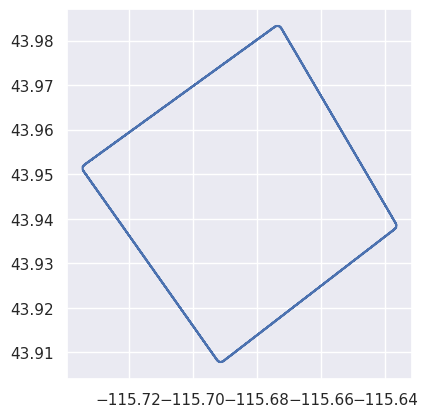

In [7]:
# check shapefile shape. i'll get kmls from HP hopefully. 
import pygeohydro as gh
import geopandas as gpd

outline = gpd.read_file('/bsuhome/julialober/scratch/coherence_data/kmls/mores_creek.shp')
outline.boundary.plot()
print(type(outline))

# project outline to UTM 
outline_utm = outline.to_crs(CRS)
outline_utm.boundary.plot()

# print(g)


# Use my new functions to load the data


In [1]:
import numpy as np 
import os
import sys
from osgeo import gdal, ogr, osr
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

import fastkml
from shapely import Polygon, box
import geopandas as gpd

# ====== import my own functions =========
import sys
import os
scripts_dir = (os.path.dirname(os.getcwd()) + '/scripts/')
sys.path.append(scripts_dir)

from layers import assemble_data

/bsuhome/julialober/miniforge3/envs/coherence/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/'

gdf = gpd.read_file(data_dir + 'kmls/hpmarshall_plan0008_all_swaths.kml', driver='KML')

polys = []
for idx, g in gdf.iterrows() : 
    polys.append(Polygon(g['geometry']))

gdf.set_geometry(polys, inplace=True, crs='EPSG:4326')
# gdf

/bsuhome/julialober/miniforge3/envs/coherence/lib/python3.13/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'hpmarshall_plan0008_all_swaths.kml': 'Radar Swaths' (default), 'Processed Swaths'. Specify layer parameter to avoid this warning.
  result = read_func(


In [3]:
mcs_aoi = gpd.read_file('/bsuhome/julialober/scratch/coherence_data/kmls/mores_creek.shp')
mcs_aoi

,id,geometry
0,1,"POLYGON ((-115.6739 43.98328, -115.67315 43.98..."


In [4]:
# print(mcs_aoi['geometry'][0])
print(box(*mcs_aoi.total_bounds))

POLYGON ((-115.63644359960277 43.90782379255037, -115.63644359960277 43.98327965211629, -115.7343221578624 43.98327965211629, -115.7343221578624 43.90782379255037, -115.63644359960277 43.90782379255037))


In [5]:
aoi = box(*mcs_aoi.total_bounds)
dates = [("20200101", "20200113"), 
         ("20210202", "20210214")]
fp_out = data_dir + 'stacks/'

In [6]:
data = assemble_data(aoi,
                     dates,
                     fp_out)
data

/bsuhome/julialober/miniforge3/envs/coherence/lib/python3.13/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge(


Got NLCD: <class 'xarray.core.dataset.Dataset'>
Making call to py3dep.get_map with resolution 30 in m.
Got DEM: <class 'xarray.core.dataarray.DataArray'>


/bsuhome/julialober/snowex_uavsar_coherence/scripts/layers.py:81: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  data = xr.merge([nlcd, dem, topo])
/bsuhome/julialober/snowex_uavsar_coherence/scripts/layers.py:81: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  data = xr.merge([nlcd, dem, topo])


<xarray.Dataset> Size: 11kB
Dimensions:      (x: 26, y: 20)
Coordinates:
    spatial_ref  int64 8B 0
  * x            (x) float64 208B -115.7 -115.7 -115.7 ... -115.6 -115.6 -115.6
  * y            (y) float64 160B 43.98 43.98 43.97 43.97 ... 43.92 43.91 43.91
    band         int64 8B 1
Data variables:
    cover_2019   (y, x) uint8 520B 52 52 71 71 52 42 42 ... 42 52 42 42 52 52 52
    canopy_2019  (y, x) float32 2kB 0.0 0.0 0.0 11.0 14.0 ... 69.0 12.0 19.0 0.0
    elevation    (y, x) float32 2kB 2.368e+03 2.393e+03 ... 2.151e+03 2.085e+03
    slope        (y, x) float32 2kB nan nan nan nan nan ... nan nan nan nan nan
    aspect       (y, x) float32 2kB nan nan nan nan nan ... nan nan nan nan nan
    curve        (y, x) float32 2kB nan nan 0.06037 nan ... 0.2224 nan nan nan
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    _FillValue:              255
    scale_factor:            1.0
    add_offset:              0.0

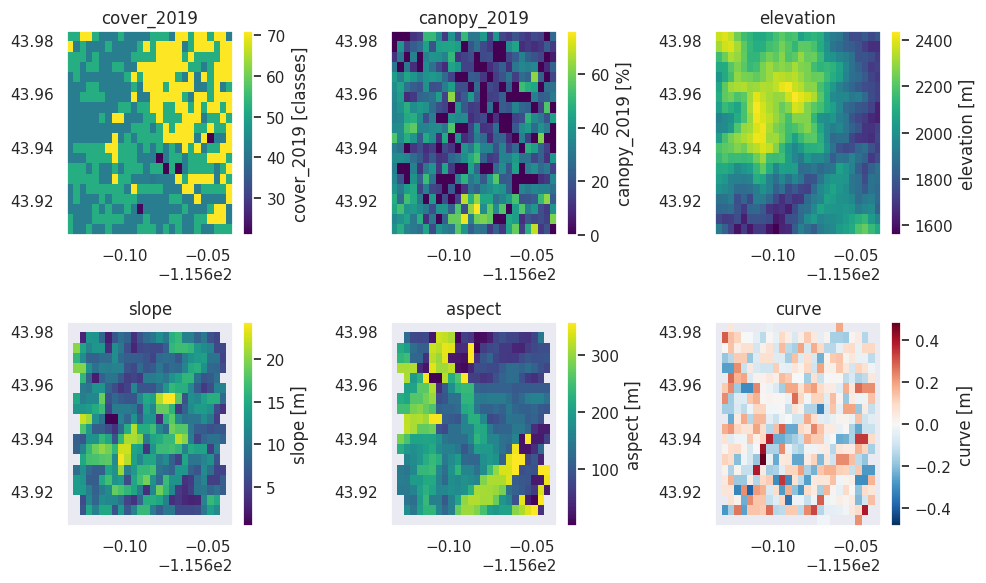

In [7]:
n = len(data)
fig, axes = plt.subplots(int(np.ceil(n / 3)), 3, figsize = (10, 6))
axes = axes.flatten()

for i, var in enumerate(data.data_vars): 
    # print(var, i)
    # print(data[var])
    data[var].plot(ax=axes[i])
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    # break

plt.tight_layout()
plt.show()

In [95]:
import pandas as pd
import warnings
from datetime import date
from datetime import datetime
import s3fs
import fsspec
import xarray as xr
def get_aorc_layers(
    aoi, 
    date_pairs, 
    crs,
    ref_grid = None
) -> xr.Dataset: 
    """
    Get AORC layers for the given AOI and date pairs. Returns a dictionary of 
    xarray DataArrays, with keys corresponding to the variable names. 

    Parameters 
    ----------
    aoi: shapely.Polygon
        A shapely Polygon geometry in EPSG:4326 (WGS84)
    date_pairs: list of tuples
        A list of (start_date, end_date) tuples, where each date is a string in 
        the format 'YYYY-MM-DD'.
    ref_grid: xarray.DataArray
        An xarray DataArray to use as a reference grid for reprojection. 

    Returns
    -------
    dict
        A dictionary of xarray DataArrays, with keys corresponding to the variable names.
    
    """
    base_url = f's3://noaa-nws-aorc-v1-1-1km'

    years = get_years(date_pairs)

    s3_out = s3fs.S3FileSystem(anon=True)
    # print(years)
    fileset = [s3fs.S3Map(
                    root=f"s3://{base_url}/{yr}.zarr", s3=s3_out, check=False
                ) for yr in years]
    ds_full = xr.open_mfdataset(fileset, engine='zarr')

    print(f'Variable size: {ds_full['APCP_surface'].nbytes/1e12:.1f} TB')
    print(aoi)
    # clip to the aoi 
    min_lon, min_lat, max_lon, max_lat = aoi.total_bounds
    ds_clip = ds_full.rio.clip_box(minx=min_lon,
                                   miny=min_lat,
                                   maxx=max_lon,
                                   maxy=max_lat)
    # ds_clip = ds_full.rio.clip(aoi.geometry.values, crs=crs)
    # print(f'Variable size: {ds_clip['APCP_surface'].nbytes/1e6:.1f} MB')


    ds = xr.Dataset()
    ds_list = []
    # get metrics for each date pair
    for i, (start_date, end_date) in enumerate(date_pairs):
        # print(ds_clip)
        ds_slice = ds_clip.sel(time=slice(start_date, end_date))
        # print(f'Variable size: {ds_slice['APCP_surface'].nbytes/1e3:.1f} KB')

        if (len(ds_slice['time']) == 0): 
            print(f'Could not get AORC data for {start_date} to {end_date}.')
            continue
        # print(start_date, end_date)

        ds_metrics = get_aorc_metrics(ds_slice)
        pair_name = start_date.strftime('%Y%m%d') + "_" + end_date.strftime('%Y%m%d')
        # ds_metrics = ds_metrics.expand_dims(dim={'pair': pair_name})
        ds_metrics['pair'] = pair_name

        ds_list.append(ds_metrics)

        # if i == 0: 
        #     ds = ds_metrics 
        # else: 
        #     print('concatenating')
        #     print(f'ds: {ds}')
        #     print(f'ds_metrics: {ds_metrics}')
        #     ds = xr.concat([ds, ds_metrics], dim='pair')

        # print(ds)

        # print(f'Variable size: {ds_slice['APCP_surface'].nbytes/1e6:.1f} MB')

        # reproject to reference grid 
        if ref_grid is not None : 
            ds_metrics = ds_metrics.rio.reproject_match(ref_grid)

    ds = xr.concat(ds_list, dim='pair')
    return ds

def get_aorc_metrics(
    aorc_ds,
    # date_pair,
    metrics = 'all'
) -> xr.Dataset:
    """
    Get a list of available AORC metrics. If list_metrics is 'all', returns a 
    list of all available metrics. If list_metrics is a list of metric names, 
    returns a list of the specified metrics. 

    Parameters 
    ----------
    list_metrics: str or list of str
        If 'all', returns a list of all available metrics. If a list of metric 
        names, returns a list of the specified metrics. Default is 'all'.

    Returns
    -------
    list of str
        A list of available AORC metrics, or the specified metrics if 
        list_metrics is a list of metric names.
    
    """

    ds = xr.Dataset()

    valid_metrics = [
        'mean_temp',
        'max_temp',
        'total_precip'
    ]

    if metrics == 'all':
        metrics = valid_metrics
    else:
        for metric in metrics:
            if metric not in valid_metrics:
                raise ValueError(f"Invalid metric: {metric}. Valid metrics are: {valid_metrics}")

    if 'mean_temp' in metrics: 
        ds['mean_temp'] = aorc_ds['APCP_surface'].mean(dim='time')
    if 'max_temp' in metrics: 
        ds['max_temp'] = aorc_ds['APCP_surface'].max(dim='time')
    if 'total_precip' in metrics: 
        ds['total_precip'] = aorc_ds['APCP_surface'].sum(dim='time')

    return ds

def get_years(
    date_pairs
): 
    years = set()
    for start_date, end_date in date_pairs:
        years.update([start_date.year, end_date.year])
    return years

def validate_date_pairs(
    dates,
    *kwargs
) -> list:
    """
    Validate and normalize a date input.
    Checks: 
    - validates each individual date using validate_date
    - checks that first date is before the second date in time. 

    Parameters
    ----------
    date_pairs : a list of date pairs. There should be two dates at each index 
        and each pair should have a beginning date first, then an ending date. 

    *kwags : optional arguments to pass along to validate_date()
    """

    # ndates = len(dates)
    ds = list()

    for idx, pair in enumerate(dates) : 
        # check that there are two dates 
        if len(pair) != 2 : 
            raise ValueError(f"Dates at index {idx} not a pair: {pair}")
        date1 = pair[0]
        date2 = pair[1]

        date1 = validate_date(date1,
                              *kwargs)
        date2 = validate_date(date2,
                              *kwargs)

        # check that dates are in the right order 
        if date2 <= date1 : 
            raise ValueError(f"Dates at index {idx} not in order: {date1}, {date2}")
        
        ds.append((date1, date2))

     # sanity check that we didn't lose anything 
    if len(dates) != len(ds) :
        raise ValueError(f"Number of dates given {len(dates)} doesn't match number of dates validated {len(ds)}")
    
    return ds 

def validate_date(
    date: str | pd.Timestamp | np.datetime64 | datetime,
    strip_timezone: bool = True,
    timezone: str | None = None,
    allow_future: bool = False,
    param_name: str = "date",
) -> pd.Timestamp:
    """
    Validate and normalize a date input.
    This function is taken directly from https://github.com/ZachHoppinen/sarvalanche/
    on 2/24/2026 

    Parameters
    ----------
    date : str | pd.Timestamp | np.datetime64 | datetime
        Date to validate. Can be string (ISO format), pandas Timestamp,
        numpy datetime64, or Python datetime.
    strip_timezone : bool, default=True
        If True, remove timezone information from the result.
        If False and timezone is None, preserve original timezone.
    timezone : str | None, default=None
        If provided, localize naive datetime or convert aware datetime
        to this timezone (e.g., 'UTC', 'US/Pacific').
        Ignored if strip_timezone is True.
    allow_future : bool, default=False
        If True, allow dates in the future. If False, raise error
        for dates after the current time.
    param_name : str, default='date'
        Name of parameter for error messages.

    Returns
    -------
    pd.Timestamp
        Validated and normalized timestamp.

    Raises
    ------
    ValueError
        If date cannot be parsed, is in the future (when allow_future=False),
        or is invalid.
    TypeError
        If date is of unsupported type.

    Examples
    --------
    >>> # Basic validation
    >>> validate_date('2024-03-15')
    Timestamp('2024-03-15 00:00:00')

    >>> # With timezone
    >>> validate_date('2024-03-15', strip_timezone=False, timezone='UTC')
    Timestamp('2024-03-15 00:00:00+0000', tz='UTC')

    >>> # Future date check
    >>> validate_date('2030-01-01')  # Raises ValueError

    >>> # Allow future dates
    >>> validate_date('2030-01-01', allow_future=True)
    Timestamp('2030-01-01 00:00:00')
    """

    # Try to convert to pandas Timestamp
    try:
        if isinstance(date, pd.Timestamp):
            ts = date
        elif isinstance(date, np.datetime64):
            ts = pd.Timestamp(date)
        elif isinstance(date, datetime):
            ts = pd.Timestamp(date)
        elif isinstance(date, str):
            ts = pd.to_datetime(date)
        else:
            raise TypeError(
                f"{param_name} must be string, pd.Timestamp, np.datetime64, "
                f"or datetime, got {type(date)}"
            )
    except (ValueError, pd.errors.ParserError) as e:
        raise ValueError(
            f"Could not parse {param_name}='{date}' as a valid date. "
            f"Error: {e}"
        ) from e

    # Check for NaT (Not a Time)
    if pd.isna(ts):
        raise ValueError(f"{param_name} is NaT (Not a Time)")

    # Handle timezone
    if strip_timezone:
        # Remove timezone info
        ts = ts.tz_localize(None) if ts.tz is not None else ts
    elif timezone is not None:
        # Apply requested timezone
        if ts.tz is None:
            # Naive datetime - localize
            ts = ts.tz_localize(timezone)
        else:
            # Already has timezone - convert
            ts = ts.tz_convert(timezone)

    # Check if date is in the future
    if not allow_future:
        now = pd.Timestamp.now(tz=ts.tz)
        if ts > now:
            raise ValueError(
                f"{param_name}='{ts}' is in the future. "
                f"Current time: {now}. "
                f"Set allow_future=True to allow future dates."
            )

    return ts

In [33]:
print(dates_val) 
print(dates_val[1])
print(dates_val[1:])

[(Timestamp('2020-01-01 00:00:00'), Timestamp('2020-01-13 00:00:00')), (Timestamp('2021-02-02 00:00:00'), Timestamp('2021-02-14 00:00:00'))]
(Timestamp('2021-02-02 00:00:00'), Timestamp('2021-02-14 00:00:00'))
[(Timestamp('2021-02-02 00:00:00'), Timestamp('2021-02-14 00:00:00'))]


In [96]:
dates = [("20200101", "20200113"), 
         ("20200101", "20200129"),
         ("20200113", "20200129"),
         ("20210202", "20210214")]
dates_val = validate_date_pairs(dates)
aorc = get_aorc_layers(mcs_aoi, dates_val, 'EPSG:4326', data['elevation'])
aorc

Variable size: 3.3 TB
   id                                           geometry
0   1  POLYGON ((-115.6739 43.98328, -115.67315 43.98...
Could not get AORC data for 2021-02-02 00:00:00 to 2021-02-14 00:00:00.


/bsuhome/julialober/miniforge3/envs/coherence/lib/python3.13/site-packages/xarray/structure/concat.py:637: UserWarning: No index created for dimension pair because variable pair is not a coordinate. To create an index for pair, please first call `.set_coords('pair')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


<xarray.Dataset> Size: 10kB
Dimensions:       (pair: 3, latitude: 10, longitude: 13)
Coordinates:
  * pair          (pair) <U17 204B '20200101_20200113' ... '20200113_20200129'
  * latitude      (latitude) float64 80B 43.91 43.92 43.92 ... 43.97 43.97 43.98
  * longitude     (longitude) float64 104B -115.7 -115.7 ... -115.6 -115.6
    spatial_ref   int64 8B 0
Data variables:
    mean_temp     (pair, latitude, longitude) float64 3kB dask.array<chunksize=(1, 10, 13), meta=np.ndarray>
    max_temp      (pair, latitude, longitude) float64 3kB dask.array<chunksize=(1, 10, 13), meta=np.ndarray>
    total_precip  (pair, latitude, longitude) float64 3kB dask.array<chunksize=(1, 10, 13), meta=np.ndarray>

In [97]:
print(aorc)

<xarray.Dataset> Size: 10kB
Dimensions:       (pair: 3, latitude: 10, longitude: 13)
Coordinates:
  * pair          (pair) <U17 204B '20200101_20200113' ... '20200113_20200129'
  * latitude      (latitude) float64 80B 43.91 43.92 43.92 ... 43.97 43.97 43.98
  * longitude     (longitude) float64 104B -115.7 -115.7 ... -115.6 -115.6
    spatial_ref   int64 8B 0
Data variables:
    mean_temp     (pair, latitude, longitude) float64 3kB dask.array<chunksize=(1, 10, 13), meta=np.ndarray>
    max_temp      (pair, latitude, longitude) float64 3kB dask.array<chunksize=(1, 10, 13), meta=np.ndarray>
    total_precip  (pair, latitude, longitude) float64 3kB dask.array<chunksize=(1, 10, 13), meta=np.ndarray>


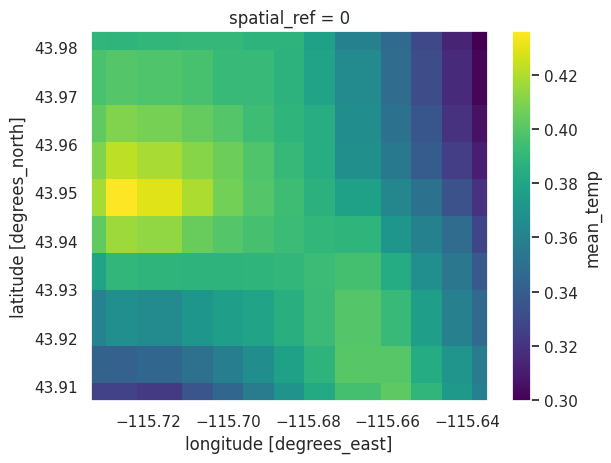

In [78]:
aorc['mean_temp'].plot()

### NLCD (Canopy cover %, Land cover type)



In [18]:
forest_cover = gh.nlcd_bygeom(geometry=outline,
                              years={'cover': [2021], 'canopy': [2021]})
print(forest_cover)

x = {}
for key, value in forest_cover.items():
    # print(key)
    x[key] = value.rio.reproject(CRS, resolution=RES)
#plot canopy and cover
# fig, axes = plt.subplots(1, 2, figsize=(8, 4))
# forest_cover[0]['canopy_2021'].plot(ax=axes[0])
# axes[0].set_title('Canopy 2021')
# forest_cover[0]['cover_2021'].plot(ax=axes[1])
# axes[1].set_title('Cover 2021')
# fig.tight_layout()
# plt.show()
print(x)

{0: <xarray.Dataset> Size: 373kB
Dimensions:      (x: 263, y: 280)
Coordinates:
  * x            (x) float64 2kB -115.7 -115.7 -115.7 ... -115.6 -115.6 -115.6
  * y            (y) float64 2kB 43.98 43.98 43.98 43.98 ... 43.91 43.91 43.91
    spatial_ref  int64 8B 0
Data variables:
    cover_2021   (y, x) uint8 74kB 127 127 127 127 127 ... 127 127 127 127 127
    canopy_2021  (y, x) float32 295kB nan nan nan nan nan ... nan nan nan nan
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    _FillValue:              255
    scale_factor:            1.0
    add_offset:              0.0}


/bsuhome/julialober/miniforge3/envs/coherence/lib/python3.13/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge(


NameError: name 'CRS' is not defined

In [33]:
# plot forest cover
print(type(forest_cover))
# print(forest_cover[0]['cover_2021'])
# print(forest_cover)

import xarray as xr
ds = xr.Dataset()
ds = forest_cover[0]
print(type(ds))
print(ds)

ds_reproj = ds.rio.reproject(CRS)


# reproject forest cover to UTM zone 11N and 30 m resolution
# fc_reproj = {}
# fc_reproj['canopy_2021'] = forest_cover[0]['canopy_2021'].rio.reproject(CRS, resolution=RES)
# fc_reproj['cover_2021'] = forest_cover[0]['cover_2021'].rio.reproject(CRS, resolution=RES)

# # replace 127 with nan in the land cover data
# fc_reproj['cover_2021'] = fc_reproj['cover_2021'].where(fc_reproj['cover_2021'] != 127, np.nan)


<class 'dict'>
<class 'xarray.core.dataset.Dataset'>
<xarray.Dataset> Size: 373kB
Dimensions:      (x: 263, y: 280)
Coordinates:
  * x            (x) float64 2kB -115.7 -115.7 -115.7 ... -115.6 -115.6 -115.6
  * y            (y) float64 2kB 43.98 43.98 43.98 43.98 ... 43.91 43.91 43.91
    spatial_ref  int64 8B 0
Data variables:
    cover_2021   (y, x) uint8 74kB 127 127 127 127 127 ... 127 127 127 127 127
    canopy_2021  (y, x) float32 295kB nan nan nan nan nan ... nan nan nan nan
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    _FillValue:              255
    scale_factor:            1.0
    add_offset:              0.0


{11: '#466b9f', 12: '#d1def8', 21: '#dec5c5', 22: '#d99282', 23: '#eb0000', 24: '#ab0000', 31: '#b3ac9f', 41: '#68ab5f', 42: '#1c5f2c', 43: '#b5c58f', 52: '#ccb879', 71: '#dfdfc2', 81: '#dcd939', 82: '#ab6c28', 90: '#b8d9eb', 95: '#6c9fb8'}
[ 0.  11.5 16.5 21.5 22.5 23.5 27.5 36.  41.5 42.5 47.5 61.5 76.  81.5
 86.  92.5 97. ]


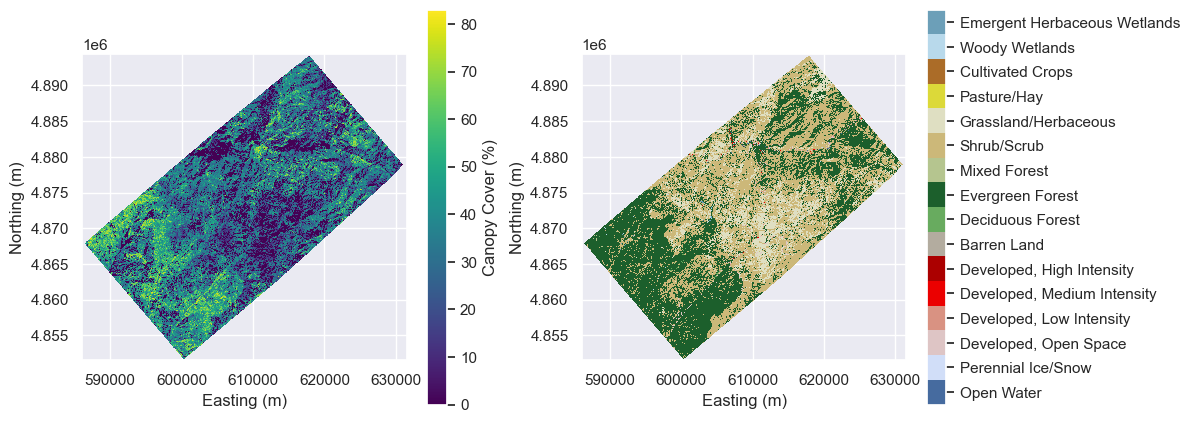

In [340]:

import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

# big ugly function to get a colormap for the land cover types  
def get_landcover_cmap() : 
    # from https://colab.research.google.com/github/gee-community/geeViz/blob/master/examples/Annual_NLCD_Viewer_Notebook.ipynb#scrollTo=a588e083
    land_cover_vis = {'LC_class_values': [11, 12, 21, 22, 23, 24, 31, 41, 42, 43, 52, 71, 81, 82, 90, 95],
    'LC_class_palette' : [
    '466b9f', 'd1def8', 'dec5c5', 'd99282', 'eb0000', 'ab0000',
    'b3ac9f', '68ab5f', '1c5f2c', 'b5c58f', 'ccb879', 'dfdfc2', 
    'dcd939', 'ab6c28', 'b8d9eb', '6c9fb8'
    ],
    'LC_class_names' : [
    "Open Water", "Perennial Ice/Snow", "Developed, Open Space", "Developed, Low Intensity", 
    "Developed, Medium Intensity", "Developed, High Intensity", "Barren Land", 
    "Deciduous Forest", "Evergreen Forest", "Mixed Forest", "Shrub/Scrub", 
    "Grassland/Herbaceous", "Pasture/Hay", "Cultivated Crops", "Woody Wetlands", 
    "Emergent Herbaceous Wetlands"
    ]
    }
    col_dict = {land_cover_vis['LC_class_values'][i]: '#' + land_cover_vis['LC_class_palette'][i] for i in range(len(land_cover_vis['LC_class_values']))}
    print(col_dict)
    # col_dict = {
    #     1:"tomato",
    #     2:"plum",
    #     7:"lightgreen",
    #     11:"green",
    #     15:"maroon",
    #     16:"aqua",
    #     17:"navy",
    #     19:"goldenrod",
    #     22:"white",
    # }
    # labels = np.array([
    #     "Urban",
    #     "I Cropland",
    #     "Grassland",
    #     "B Deciduous",
    #     "Mixed Forest",
    #     "Water Bodies",
    #     "H Wetland", 
    #     "Barren",
    #     "Tundra",
    # ])
    ncolors = len(col_dict.keys())
    cm = ListedColormap([col_dict[x] for x in col_dict.keys()])
    np.random.seed(2112)
    lu_index = np.zeros((ncolors, ncolors))
    for nn,k in enumerate(col_dict.keys()):
        lu_index[nn, :] = k

    bounds = np.array([k for k in col_dict.keys()])
    bounds = bounds[:-1] + np.diff(bounds) / 2
    bounds = np.concatenate((np.array([0]), bounds, np.array([97])))
    norm = mcolors.BoundaryNorm(bounds, ncolors)
    return cm, norm, bounds

cover_cmap, cover_norm, cover_bounds = get_landcover_cmap()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

img1 = fc_reproj['canopy_2021'].plot(ax=axes[0], add_colorbar=False)
axes[0].set_title('')
axes[0].set_aspect('equal')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
axes[0].grid(True)
fig.colorbar(img1, ax=axes[0], shrink=0.7, label='Canopy Cover (%)')

# set a colorbar for the NLCD land cover types 
# cmap = land_cover_vis['LC_class_palette']
cover_class_names = [
    "Open Water", "Perennial Ice/Snow", "Developed, Open Space", 
    "Developed, Low Intensity", "Developed, Medium Intensity", 
    "Developed, High Intensity", "Barren Land", "Deciduous Forest", 
    "Evergreen Forest", "Mixed Forest", "Shrub/Scrub", "Grassland/Herbaceous", 
    "Pasture/Hay", "Cultivated Crops", "Woody Wetlands", 
    "Emergent Herbaceous Wetlands"
    ]
img2 =fc_reproj['cover_2021'].plot(ax=axes[1], 
                                   cmap=cover_cmap, 
                                   norm=cover_norm, 
                                   levels=cover_bounds,
                                   add_colorbar=False)
axes[1].set_title('')
axes[1].set_aspect('equal')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')
axes[1].grid(True)
print(cover_bounds)
cbar = fig.colorbar(img2, ax=axes[1], shrink=0.7)
cbar.set_ticks((cover_bounds[:-1] + np.diff(cover_bounds) / 2), labels=cover_class_names) 
cbar.minorticks_off()

fig.tight_layout()
plt.show()

### DEM (Elevation, Slope, Aspect, Curvature) 

Use the 3DEP API to get a dem. 

In [11]:
import py3dep 
from shapely import box 

aoi = box(*mcs_aoi.total_bounds)
print(type(aoi))
# plt.plot(*aoi.exterior.xy)
dem_da = py3dep.get_map("DEM", geometry=aoi, resolution=RES, crs= 'EPSG:4326')
dem_da.rio.reproject('EPSG:4326', inplace=True).rio.write_crs('EPSG:4326', inplace=True)
# box
# plot(*outline.total_bounds)
# slc_bounds 

<class 'shapely.geometry.polygon.Polygon'>


<xarray.DataArray 'elevation' (y: 259, x: 336)> Size: 348kB
array([[2320.3555, 2327.207 , 2335.2197, ..., 1827.5416, 1827.5416,
        1814.1205],
       [2326.615 , 2332.7495, 2339.2922, ..., 1833.5042, 1821.2291,
        1807.646 ],
       [2331.8066, 2337.4988, 2342.853 , ..., 1827.5964, 1815.0593,
        1801.475 ],
       ...,
       [1949.8483, 1949.078 , 1943.7582, ..., 2084.3926, 2090.5747,
        2079.8235],
       [1942.7524, 1940.1074, 1936.0474, ..., 2068.9456, 2059.2527,
        2063.7651],
       [1931.7762, 1922.9447, 1920.0044, ..., 2038.2194, 2042.854 ,
        2048.145 ]], shape=(259, 336), dtype=float32)
Coordinates:
  * x            (x) float64 3kB -115.7 -115.7 -115.7 ... -115.6 -115.6 -115.6
  * y            (y) float64 2kB 43.98 43.98 43.98 43.98 ... 43.91 43.91 43.91
    spatial_ref  int64 8B 0
Attributes:
    DataType:         Generic
    AREA_OR_POINT:    Area
    SourceBandIndex:  0
    scale_factor:     1.0
    add_offset:       0.0
    _FillValue:       nan

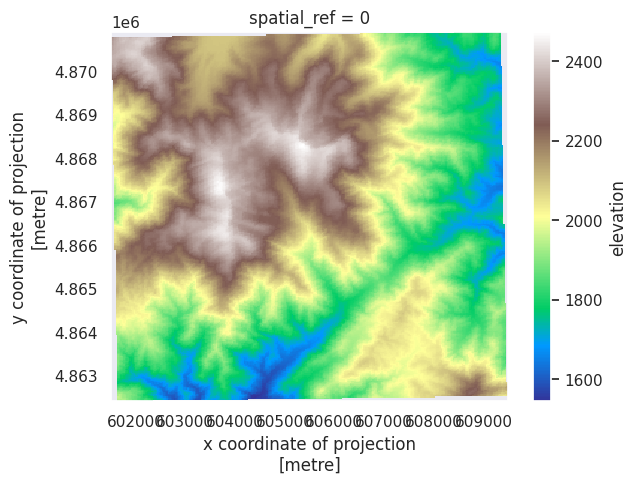

In [12]:
dem_reproj = dem_da.rio.reproject(CRS, resolution=RES)
dem_reproj.plot(cmap='terrain')

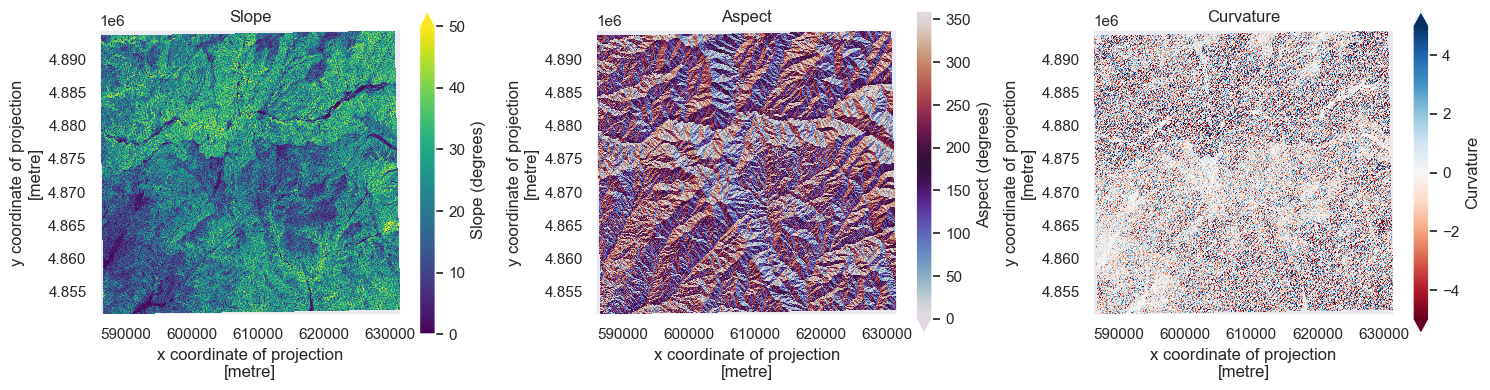

In [162]:
import xrspatial as xrs
import xarray as xr

slope = xrs.slope(dem_reproj)
aspect = xrs.aspect(dem_reproj)
curvature = xrs.curvature(dem_reproj)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
slope.plot(ax=axes[0], 
           cmap='viridis', 
           vmin=0, vmax=50,
           cbar_kwargs={'label': 'Slope (degrees)', 
                        'shrink':0.7})
axes[0].set_title('Slope')
axes[0].set_aspect('equal')
aspect.plot(ax=axes[1], 
            cmap='twilight', 
            vmin=0, vmax=360,
            cbar_kwargs={'label': 'Aspect (degrees)', 
                         'shrink':0.7})
axes[1].set_title('Aspect')
axes[1].set_aspect('equal')
curvature.plot(ax=axes[2], 
               cmap='RdBu', 
               vmin=-5, vmax=5,
               cbar_kwargs={'label': 'Curvature', 
                            'shrink':0.7})
axes[2].set_title('Curvature')
axes[2].set_aspect('equal')
fig.tight_layout()
plt.show()


### Get UCLA Snow Reanalysis data from NSIDC

In [227]:
import earthaccess 
auth = earthaccess.login()
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)

download_dir = '../data/wus_ucla_sr/'

In [206]:
print(aoi.wkt)
print(outline.total_bounds)

# make points from total bounds 
points = [(outline.total_bounds[0], outline.total_bounds[1]),
          (outline.total_bounds[0], outline.total_bounds[3]),
          (outline.total_bounds[2], outline.total_bounds[3]),
          (outline.total_bounds[2], outline.total_bounds[1]),
          (outline.total_bounds[0], outline.total_bounds[1])]
# reverse order for earthaccess
points = points[::-1]

POLYGON ((-115.36466217041016 43.811424255371094, -115.36466217041016 44.191368103027344, -115.92279052734375 44.191368103027344, -115.92279052734375 43.811424255371094, -115.36466217041016 43.811424255371094))
[-115.92279053   43.81142426 -115.36466217   44.1913681 ]


In [228]:
grans = earthaccess.search_data(
    short_name='WUS_UCLA_SR', 
    cloud_hosted=True, 
    temporal=('2019-12', '2021-04'),
    polygon=points
)
print(len(grans))
if (len(grans) < 10) : 
    print(grans)

8
[Collection: {'EntryTitle': 'Western United States UCLA Daily Snow Reanalysis V001'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -115.998, 'EastBoundingCoordinate': -115.001, 'NorthBoundingCoordinate': 43.9978, 'SouthBoundingCoordinate': 43.0023}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2019-10-01T00:00:00.000Z', 'EndingDateTime': '2020-09-30T23:59:59.000Z'}}
Size(MB): 169.37
Data: ['https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/SNOWEX/WUS_UCLA_SR/1/2019/10/01/WUS_UCLA_SR_v01_N43_0W116_0_agg_16_WY2019_20_SWE_SCA_POST.nc'], Collection: {'EntryTitle': 'Western United States UCLA Daily Snow Reanalysis V001'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -115.998, 'EastBoundingCoordinate': -115.001, 'NorthBoundingCoordinate': 43.9978, 'SouthBoundingCoordinate': 43.0023}]}}}
Temporal coverage: {'RangeDateTime': {

In [212]:
grans[0]

Collection: {'EntryTitle': 'Western United States UCLA Daily Snow Reanalysis V001'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -115.998, 'EastBoundingCoordinate': -115.001, 'NorthBoundingCoordinate': 43.9978, 'SouthBoundingCoordinate': 43.0023}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2019-10-01T00:00:00.000Z', 'EndingDateTime': '2020-09-30T23:59:59.000Z'}}
Size(MB): 169.37
Data: ['https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/SNOWEX/WUS_UCLA_SR/1/2019/10/01/WUS_UCLA_SR_v01_N43_0W116_0_agg_16_WY2019_20_SWE_SCA_POST.nc']

In [ ]:
# grans[0].data_links(access="out_of_region")

['https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/SNOWEX/WUS_UCLA_SR/1/2019/10/01/WUS_UCLA_SR_v01_N43_0W116_0_agg_16_WY2019_20_SWE_SCA_POST.nc']

I will stream the data directly to xarray without downloading to my machine. This may not matter in the future... 

In [ ]:
fileset = earthaccess.open(grans)
ds = xr.open_mfdataset(fileset, chunks={})

QUEUEING TASKS | : 100%|██████████| 8/8 [00:00<00:00, 961.22it/s]
PROCESSING TASKS | : 100%|██████████| 8/8 [00:01<00:00,  4.40it/s]
COLLECTING RESULTS | : 100%|██████████| 8/8 [00:00<00:00, 95325.09it/s]


In [232]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:    (Day: 365, Stats: 5, Longitude: 225, Latitude: 450)
Coordinates:
  * Longitude  (Longitude) float32 900B -116.0 -116.0 -116.0 ... -115.0 -115.0
  * Latitude   (Latitude) float32 2kB 45.0 44.99 44.99 ... 43.01 43.01 43.0
Dimensions without coordinates: Day, Stats
Data variables:
    SWE_Post   (Day, Stats, Longitude, Latitude) float32 739MB dask.array<chunksize=(1, 5, 225, 225), meta=np.ndarray>
    SCA_Post   (Day, Stats, Longitude, Latitude) float32 739MB dask.array<chunksize=(1, 5, 225, 225), meta=np.ndarray>
    SD_Post    (Day, Stats, Longitude, Latitude) float32 739MB dask.array<chunksize=(1, 5, 225, 225), meta=np.ndarray>

In [233]:
ds.keys()

KeysView(<xarray.Dataset> Size: 2GB
Dimensions:    (Day: 365, Stats: 5, Longitude: 225, Latitude: 450)
Coordinates:
  * Longitude  (Longitude) float32 900B -116.0 -116.0 -116.0 ... -115.0 -115.0
  * Latitude   (Latitude) float32 2kB 45.0 44.99 44.99 ... 43.01 43.01 43.0
Dimensions without coordinates: Day, Stats
Data variables:
    SWE_Post   (Day, Stats, Longitude, Latitude) float32 739MB dask.array<chunksize=(1, 5, 225, 225), meta=np.ndarray>
    SCA_Post   (Day, Stats, Longitude, Latitude) float32 739MB dask.array<chunksize=(1, 5, 225, 225), meta=np.ndarray>
    SD_Post    (Day, Stats, Longitude, Latitude) float32 739MB dask.array<chunksize=(1, 5, 225, 225), meta=np.ndarray>)

In [266]:
# plot one day of SWE over the study area 
day = '2020-04-01'
# get days between day and 2019-10-01
day_diff = (np.datetime64(day) - np.datetime64('2019-10-01')).astype(int)
print(day_diff) 
# get day diff as int
swe = ds['SWE_Post']
swe.rio.write_crs('EPSG:4326', inplace=True)
swe_day = swe.loc[swe['Day'] == day_diff]
# print(swe['Day'].values)
print(swe_day)
# print(swe_day['Day'] == day)

183
<xarray.DataArray 'SWE_Post' (Day: 1, Stats: 5, Longitude: 225, Latitude: 450)> Size: 2MB
dask.array<getitem, shape=(1, 5, 225, 450), dtype=float32, chunksize=(1, 5, 225, 225), chunktype=numpy.ndarray>
Coordinates:
  * Longitude    (Longitude) float32 900B -116.0 -116.0 -116.0 ... -115.0 -115.0
  * Latitude     (Latitude) float32 2kB 45.0 44.99 44.99 ... 43.01 43.01 43.0
    spatial_ref  int64 8B 0
Dimensions without coordinates: Day, Stats
Attributes:
    Units:    meters


In [280]:
snow_prods = [ds['SWE_Post'].loc[ds['Day'] == day_diff],
              ds['SCA_Post'].loc[ds['Day'] == day_diff],
              ds['SD_Post'].loc[ds['Day'] == day_diff]]
snow_prods

[<xarray.DataArray 'SWE_Post' (Day: 1, Stats: 5, Longitude: 225, Latitude: 450)> Size: 2MB
 dask.array<getitem, shape=(1, 5, 225, 450), dtype=float32, chunksize=(1, 5, 225, 225), chunktype=numpy.ndarray>
 Coordinates:
   * Longitude  (Longitude) float32 900B -116.0 -116.0 -116.0 ... -115.0 -115.0
   * Latitude   (Latitude) float32 2kB 45.0 44.99 44.99 ... 43.01 43.01 43.0
 Dimensions without coordinates: Day, Stats
 Attributes:
     Units:    meters,
 <xarray.DataArray 'SCA_Post' (Day: 1, Stats: 5, Longitude: 225, Latitude: 450)> Size: 2MB
 dask.array<getitem, shape=(1, 5, 225, 450), dtype=float32, chunksize=(1, 5, 225, 225), chunktype=numpy.ndarray>
 Coordinates:
   * Longitude  (Longitude) float32 900B -116.0 -116.0 -116.0 ... -115.0 -115.0
   * Latitude   (Latitude) float32 2kB 45.0 44.99 44.99 ... 43.01 43.01 43.0
 Dimensions without coordinates: Day, Stats
 Attributes:
     Units:    [-],
 <xarray.DataArray 'SD_Post' (Day: 1, Stats: 5, Longitude: 225, Latitude: 450)> Size: 2MB
 da

In [343]:
# for prod in snow_prods:
#     prod.rio.write_crs('EPSG:4326', inplace=True)
#     prod.rio.set_spatial_dims(x_dim='Longitude', y_dim='Latitude', inplace=True)
snow_prods_mean_reproj = []
for prod in snow_prods:
    # print(prod)
    # unchunk the dask arrawy to reproject with rioxarray
    # prod = prod.compute()
    # prod.rio.write_crs('EPSG:4326', inplace=True)
    # prod.rio.set_spatial_dims(x_dim='Longitude', y_dim='Latitude', inplace=True)
    # print(prod[0, 0])
    da = prod.sel(Stats = 2)
    da = da.rio.write_crs('EPSG:4326')
    da = da.rename({'Longitude': 'x', 'Latitude': 'y', 'Day': 'dowy'}).transpose('dowy', 'y', 'x')
    # prod[0, 0].rio.set_spatial_dims(x_dim='Longitude', y_dim='Latitude', inplace=True)
    print(da)
    # print(prod[0, 0]['Latitude'])
    # get std dev of spacing in lat and lon
    # print('confirm evenly spaced grid')
    # print("lat spacing:", np.std(np.diff(prod[0, 0]['Latitude'].values)))
    # print("lon spacing:", np.std(np.diff(prod[0, 0]['Longitude'].values)))

    prod_reproj = da.rio.reproject(CRS, resolution=RES)
    snow_prods_mean_reproj.append(prod_reproj)

<xarray.DataArray 'SWE_Post' (dowy: 1, y: 450, x: 225)> Size: 405kB
dask.array<transpose, shape=(1, 450, 225), dtype=float32, chunksize=(1, 225, 225), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float32 2kB 45.0 44.99 44.99 44.98 ... 43.01 43.01 43.0
  * x            (x) float32 900B -116.0 -116.0 -116.0 ... -115.0 -115.0 -115.0
    spatial_ref  int64 8B 0
Dimensions without coordinates: dowy
Attributes:
    Units:    meters
<xarray.DataArray 'SCA_Post' (dowy: 1, y: 450, x: 225)> Size: 405kB
dask.array<transpose, shape=(1, 450, 225), dtype=float32, chunksize=(1, 225, 225), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float32 2kB 45.0 44.99 44.99 44.98 ... 43.01 43.01 43.0
  * x            (x) float32 900B -116.0 -116.0 -116.0 ... -115.0 -115.0 -115.0
    spatial_ref  int64 8B 0
Dimensions without coordinates: dowy
Attributes:
    Units:    [-]
<xarray.DataArray 'SD_Post' (dowy: 1, y: 450, x: 225)> Size: 405kB
dask.array<transpose, shape=(1, 450, 225), dtype

In [273]:
print(swe_day['Longitude'].shape)
print(swe_day['Latitude'].shape)
print(swe_day[0,0].shape)

(225,)
(450,)
(225, 450)


<xarray.DataArray 'SWE_Post' (dowy: 1, y: 7450, x: 2802)> Size: 83MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(1, 7450, 2802), dtype=float32)
Coordinates:
  * y            (y) float64 60kB 4.985e+06 4.985e+06 ... 4.761e+06 4.761e+06
  * x            (x) float64 22kB 5.788e+05 5.789e+05 ... 6.628e+05 6.629e+05
    spatial_ref  int64 8B 0
Dimensions without coordinates: dowy
Attributes:
    Units:    meters
<xarray.DataArray 'SCA_Post' (dowy: 1, y: 7450, x: 2802)> Size: 83MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ...,

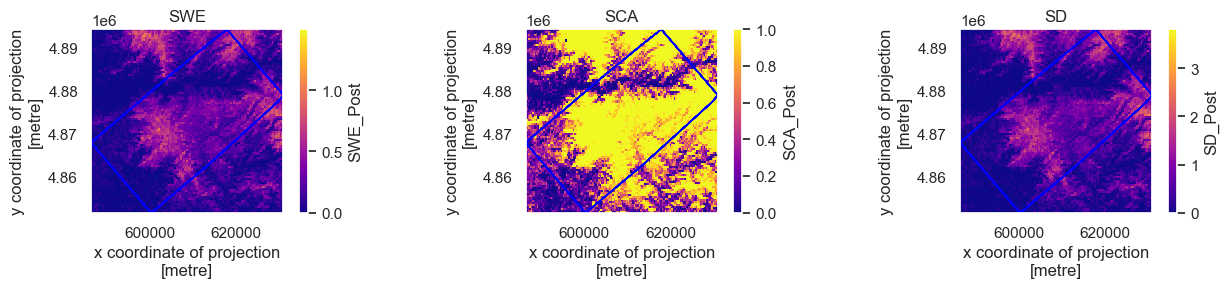

In [345]:
# plot swe_day, trim to outline
names = ['SWE', 'SCA', 'SD']
fig, axes = plt.subplots(1, 3, figsize=(13, 3))

for prod, name, ax in zip(snow_prods_mean_reproj, names, axes):
    # im = ax.contourf(prod['Longitude'], prod['Latitude'], prod[0,0].T)
    print(prod)
    # im = ax.imshow(prod.T,
    #                 # extent=(prod['x'].min(), prod['x'].max(), 
    #                 #         prod['y'].min(), prod['y'].max()),
    #                 origin='lower')
    im = prod.plot(ax=ax, cmap='plasma', add_colorbar=False)
    outline_utm.boundary.plot(ax=ax, edgecolor='blue', linewidth=1)
    ax.set_xlim(outline_utm.total_bounds[0], outline_utm.total_bounds[2])
    ax.set_ylim(outline_utm.total_bounds[1], outline_utm.total_bounds[3])
    ax.set_aspect('equal')
    ax.set_title(name)
    # ax.grid(False)
    fig.colorbar(im, ax=ax, label=prod.name)
fig.tight_layout()
plt.show()
# plt.figure(figsize=(8, 6))
# plt.contourf(swe_day['Longitude'], swe_day['Latitude'], swe_day[0,0].T)
# plt.xlim(outline.total_bounds[0], outline.total_bounds[2])
# plt.ylim(outline.total_bounds[1], outline.total_bounds[3])
# plt.title(f'SWE on {day}')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.colorbar(label='SWE (m)')
# plt.show()

TODO: write functions for downloading each of these data layers. 

# HRRR

Trying to get HRRR through the zarr database so that I can do easy subsetting. This code is all copied from [this page.](https://mesowest.utah.edu/html/hrrr/zarr_documentation/html/xarray_one_day_analysis_example.html)

In [377]:
import s3fs
import xarray as xr
from pyproj import CRS
import datetime
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numcodecs as ncd

fs = s3fs.S3FileSystem(anon=True)


In [386]:
zone = "5.2"

crs = CRS.from_proj4(
    "+proj=lcc +lat_1=38.5 +lat_2=38.5 "
    "+lat_0=38.5 +lon_0=262.5 "
    "+a=6371229 +b=6371229 +units=m +no_defs"
)

projection = ccrs.LambertConformal(central_longitude=262.5, 
                                   central_latitude=38.5, 
                                   standard_parallels=(38.5, 38.5),
                                    globe=ccrs.Globe(semimajor_axis=6371229,
                                                     semiminor_axis=6371229))

def load_dataset(urls):
    fs = s3fs.S3FileSystem(anon=True)
    print(urls)
    ds = xr.open_mfdataset([s3fs.S3Map(url, s3=fs) for url in urls], engine='zarr')
    ds = ds.rename(projection_x_coordinate="x", projection_y_coordinate="y")
    ds = ds.rio.write_crs(crs, inplace=False)
    ds = ds.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=False)
    ds = ds.set_coords("time")
    return ds

def load_combined_dataset(start_date, num_hours, level, param_short_name):
    combined_ds = None
    for i in range(num_hours):
        time = start_date + datetime.timedelta(hours=i)
        group_url = time.strftime(f"s3://hrrrzarr/sfc/%Y%m%d/%Y%m%d_%Hz_anl.zarr/{level}/{param_short_name}")
        subgroup_url = f"{group_url}/{level}/{param_short_name}/{zone}"
        # partial_ds = load_dataset([subgroup_url])
        partial_ds = retrieve_data(subgroup_url)
        if combined_ds is None:
            combined_ds = partial_ds
        else:
            combined_ds = xr.concat([combined_ds, partial_ds], dim="time", combine_attrs="drop_conflicts")
    return combined_ds

def retrieve_data(s3_url):
    with fs.open(s3_url, 'rb') as compressed_data: # using s3fs
        print(f"Retrieving data from: {s3_url}")
        buffer = ncd.blosc.decompress(compressed_data.read())

        dtype = "<f2" # See variables background page and python data loading
                      # guide for info on when you need a different dtype

        chunk = np.frombuffer(buffer, dtype=dtype)
        
        entry_size = 150*150
        num_entries = len(chunk)//entry_size

        if num_entries == 1: # analysis file is 2d
            data_array = np.reshape(chunk, (150, 150))
        else:
            data_array = np.reshape(chunk, (num_entries, 150, 150))

    return data_array

In [387]:
%%time
ds = load_combined_dataset(datetime.datetime(2021, 4, 1), 4, "2m_above_ground", "TMP")
# sfc/20210401/20210401_00z_anl.zarr/2m_above_ground/TMP/2m_above_ground/TMP/

Retrieving data from: s3://hrrrzarr/sfc/20210401/20210401_00z_anl.zarr/2m_above_ground/TMP/2m_above_ground/TMP/5.2
Retrieving data from: s3://hrrrzarr/sfc/20210401/20210401_01z_anl.zarr/2m_above_ground/TMP/2m_above_ground/TMP/5.2
CPU times: user 10.5 ms, sys: 11.6 ms, total: 22.1 ms
Wall time: 451 ms


TypeError: can only concatenate xarray Dataset and DataArray objects, got <class 'numpy.ndarray'>

In [356]:
std_dev = ds.TMP.std(dim="time")
std_dev.values

array([[0.2166, 0.2166, 0.2166, ..., 0.2166, 0.2166, 0.2166],
       [0.2166, 0.2166, 0.2166, ..., 0.2166, 0.2166, 0.2166],
       [0.2166, 0.2166, 0.2166, ..., 0.2166, 0.2166, 0.2166],
       ...,
       [0.2166, 0.3062, 0.2795, ..., 0.25  , 0.25  , 0.1768],
       [0.2166, 0.2166, 0.3062, ..., 0.3062, 0.2795, 0.2795],
       [0.2166, 0.2166, 0.2166, ..., 0.2795, 0.2795, 0.25  ]],
      shape=(1059, 1799), dtype=float16)

/Users/JULIALOBER/miniforge3/envs/coherence/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


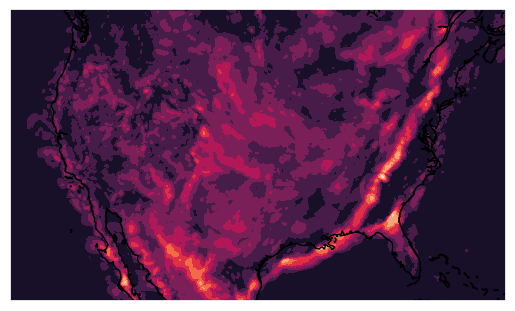

In [361]:
ax = plt.axes(projection=projection)
ax.contourf(std_dev.x, std_dev.y, std_dev)
ax.coastlines()

plt.show()

In [397]:
import datetime
import xarray as xr
import rioxarray
import s3fs
from pyproj import CRS

# Official HRRR spherical Lambert Conformal
HRRR_CRS = CRS.from_proj4(
    "+proj=lcc "
    "+lat_1=38.5 +lat_2=38.5 "
    "+lat_0=38.5 +lon_0=-97.5 "
    "+a=6371229 +b=6371229 "
    "+units=m +no_defs"
)

def load_hrrr_chunk_bbox(
    start_time,
    end_time,
    level,
    parameter,
    zone,    # e.g. "3.7"
    bbox     # (min_lon, min_lat, max_lon, max_lat) in EPSG:4326
):
    """
    Returns DataArray with dims (time, y, x) in EPSG:4326
    """

    # --- Default midnight handling ---
    if isinstance(start_time, datetime.date) and not isinstance(start_time, datetime.datetime):
        start_time = datetime.datetime.combine(start_time, datetime.time(0))

    if isinstance(end_time, datetime.date) and not isinstance(end_time, datetime.datetime):
        end_time = datetime.datetime.combine(end_time, datetime.time(0))

    row, col = map(int, zone.split("."))

    datasets = []
    current_time = start_time

    while current_time <= end_time:

        url = current_time.strftime(
            f"hrrrzarr/sfc/%Y%m%d/%Y%m%d_%Hz_anl.zarr/"
            f"{level}/{parameter}/"
            f"{level}/{parameter}/"
            f"{zone}"
        )

        print(f"Loading {current_time} | chunk {zone}")

        with fs.open(url, "rb") as f:
            buffer = ncd.blosc.decompress(f.read())
            data = np.frombuffer(buffer, dtype="<f2").reshape(150, 150)

        # Compute global HRRR grid indices
        x_start = col * 150
        y_start = row * 150

        x = np.arange(x_start, x_start + 150)
        y = np.arange(y_start, y_start + 150)

        da = xr.DataArray(
            data,
            dims=("y", "x"),
            coords={"x": x, "y": y},
            name=parameter
        )

        print(da)

        # Attach native HRRR projection
        da = da.rio.set_spatial_dims(x_dim="x", y_dim="y")
        da = da.rio.write_crs(HRRR_CRS)

        # Reproject to geographic
        da_geo = da.rio.reproject("EPSG:4326")

        # Clip to bounding box
        min_lon, min_lat, max_lon, max_lat = bbox
        da_clip = da_geo.rio.clip_box(
            minx=min_lon,
            miny=min_lat,
            maxx=max_lon,
            maxy=max_lat
        )

        # Add time dimension
        da_clip = da_clip.expand_dims(time=[current_time])

        datasets.append(da_clip)

        current_time += datetime.timedelta(hours=1)

    combined = xr.concat(datasets, dim="time")

    return combined

In [398]:
load_hrrr_chunk_bbox(
    start_time = datetime.datetime(2021, 4, 1, 0),
    end_time = datetime.datetime(2021, 4, 13, 0),
    level = '2m_above_ground',
    parameter = 'TMP',
    zone = '5.2',   # e.g. "3.7"
    bbox = outline.total_bounds    # (min_lon, min_lat, max_lon, max_lat) in EPSG:4326
)

Loading 2021-04-01 00:00:00 | chunk 5.2
<xarray.DataArray 'TMP' (y: 150, x: 150)> Size: 45kB
array([[290.8, 291.8, 292. , ..., 283.5, 283.5, 283.5],
       [291. , 291.8, 292. , ..., 283.2, 283.2, 283.2],
       [291.2, 291.8, 292.2, ..., 282. , 283. , 283. ],
       ...,
       [284.5, 285.5, 287.2, ..., 279. , 277.2, 277.2],
       [285. , 286. , 287.5, ..., 277.8, 276.2, 278.2],
       [283.2, 286. , 287. , ..., 275.5, 276. , 278. ]],
      shape=(150, 150), dtype=float16)
Coordinates:
  * y        (y) int64 1kB 750 751 752 753 754 755 ... 894 895 896 897 898 899
  * x        (x) int64 1kB 300 301 302 303 304 305 ... 444 445 446 447 448 449


KeyError: 'float16'

In [399]:
chunk_index = xr.open_zarr(s3fs.S3Map("s3://hrrrzarr/grid/HRRR_chunk_index.zarr", s3=fs))
chunk_index

<xarray.Dataset> Size: 46MB
Dimensions:     (x: 1799, y: 1059)
Coordinates:
  * x           (x) float64 14kB -2.698e+06 -2.695e+06 ... 2.693e+06 2.696e+06
  * y           (y) float64 8kB -1.587e+06 -1.584e+06 ... 1.584e+06 1.587e+06
Data variables:
    chunk_id    (x, y) object 15MB dask.array<chunksize=(1799, 1059), meta=np.ndarray>
    chunk_x     (x) int32 7kB dask.array<chunksize=(1799,), meta=np.ndarray>
    chunk_y     (y) int32 4kB dask.array<chunksize=(1059,), meta=np.ndarray>
    in_chunk_x  (x) int32 7kB dask.array<chunksize=(1799,), meta=np.ndarray>
    in_chunk_y  (y) int32 4kB dask.array<chunksize=(1059,), meta=np.ndarray>
    index_x     (x) int32 7kB dask.array<chunksize=(1799,), meta=np.ndarray>
    index_y     (y) int32 4kB dask.array<chunksize=(1059,), meta=np.ndarray>
    latitude    (y, x) float64 15MB dask.array<chunksize=(133, 450), meta=np.ndarray>
    longitude   (y, x) float64 15MB dask.array<chunksize=(133, 450), meta=np.ndarray>

# AORC - model suggested by Zach Butler

AORC specs: 
- hosted on AWS in .zarr format 
- either 1km or 800m resolution 
- variables of interest: TMP_2maboveground, APCP_surface, UGRD_10maboveground, VGRD_10maboveground

Workflow for using the AORC: 
1. get array of datetime flight times 
2. open .zarr for appropriate year 
3. clip to bounding box 
4. for each flight: <br>
    a. select the start/end times <br> 
    b. calculate all metrics <br> 
    c. save each metric as a nc file

In [ ]:
def get_aorc(geometry, 
             out_fp,
             dates,
             vars = ['temp', 'precip', 'wind'],
             crs_dest='EPSG:26911',
             res_dest=30) :
    
    import fsspec
    
    base_url = f's3://noaa-nws-aorc-v1-1-1km'

    years = set([date.year for date in dates])

    if len(years) > 2 : 
        print("Too many years requested, can't handle that yet")
        return

    # zarr_urls = [f'{base_url}/{year}.zarr/' for year in years]
    # raw = xr.open_zarr(fsspec.get_mapper(single_year_url, anon=True), 
    #                     consolidated=True)
    
    s3_out = s3fs.S3FileSystem(anon=True)
    fileset = [s3fs.S3Map(
                root=f"s3://{base_url}/{yr}.zarr", s3=s3_out, check=False
            ) for yr in years]
    full_ds = xr.open_mfdataset(fileset, engine='zarr')

    for begin_date, end_date in zip(dates[:-1], dates[1:]):
        # begin_year = begin_date.year
        # end_year = end_date.year
        # if begin_year != end_year:
        #     print("Can't handle date ranges that span multiple years yet")
        #     print(f"begin_date: {begin_date}, end_date: {end_date}")
        #     continue
        
        # load the full zarr year
        # single_year_url = f'{base_url}/{begin_year}.zarr/'
        # raw = xr.open_zarr(fsspec.get_mapper(single_year_url, anon=True), 
        #                 consolidated=True)
        min_lon, min_lat, max_lon, max_lat = outline.total_bounds

        # clip to the bounds 
        clipped = full_ds.rio.clip_box(minx=min_lon,
                                       miny=min_lat,
                                       maxx=max_lon,
                                       maxy=max_lat)
        clipped = clipped.sel(time=slice(begin_date, end_date))

        # calculate metrics 
        # for now just get mean temp at 2m above ground
        avg_temp_2m = clipped['TMP_2maboveground'].mean(dim='time')

        # degrees_above_0 = np.sum(clipped.sel['TMP_2maboveground'] > 273.15, dim='time')


In [58]:
s3_out = s3fs.S3FileSystem(anon=True)
fileset = [s3fs.S3Map(
                root=f"s3://{base_url}/{yr}.zarr", s3=s3_out, check=False
            ) for yr in (2020, 2021)]
full_ds = xr.open_mfdataset(fileset, engine='zarr')
min_lon, min_lat, max_lon, max_lat = mcs_aoi.total_bounds
full_ds_clip = full_ds.rio.clip_box(minx=min_lon,
                                       miny=min_lat,
                                       maxx=max_lon,
                                       maxy=max_lat)

In [451]:
full_ds_clip
print(f'Variable size: {full_ds['TMP_2maboveground'].nbytes/1e12:.1f} TB')
print(f'Variable size: {full_ds_clip['TMP_2maboveground'].nbytes/1e6:.1f} MB')

Variable size: 5.0 TB
Variable size: 448.6 MB


In [36]:
base_url = f's3://noaa-nws-aorc-v1-1-1km'
year = '2020'
single_year_url = f'{base_url}/{year}.zarr/'
import fsspec

In [37]:
%%time
ds_single = xr.open_zarr(fsspec.get_mapper(single_year_url, anon=True), consolidated=True)

CPU times: user 232 ms, sys: 11.1 ms, total: 243 ms
Wall time: 1.96 s


In [405]:
print(f'Variable size: {ds_single['TMP_2maboveground'].nbytes/1e12:.1f} TB')

Variable size: 2.5 TB


In [406]:
print(outline.total_bounds)

[-115.92279053   43.81142426 -115.36466217   44.1913681 ]


In [40]:
min_lon, min_lat, max_lon, max_lat = mcs_aoi.total_bounds

da_clip = ds_single.rio.clip_box(
            minx=min_lon,
            miny=min_lat,
            maxx=max_lon,
            maxy=max_lat
        )

<xarray.Dataset> Size: 24B
Dimensions:              (time: 0)
Coordinates:
    latitude             float64 8B 43.95
    longitude            float64 8B -115.7
  * time                 (time) datetime64[ns] 0B 
    spatial_ref          int64 8B 0
Data variables:
    APCP_surface         (time) float64 0B dask.array<chunksize=(0,), meta=np.ndarray>
    DLWRF_surface        (time) float64 0B dask.array<chunksize=(0,), meta=np.ndarray>
    DSWRF_surface        (time) float64 0B dask.array<chunksize=(0,), meta=np.ndarray>
    PRES_surface         (time) float64 0B dask.array<chunksize=(0,), meta=np.ndarray>
    SPFH_2maboveground   (time) float64 0B dask.array<chunksize=(0,), meta=np.ndarray>
    TMP_2maboveground    (time) float64 0B dask.array<chunksize=(0,), meta=np.ndarray>
    UGRD_10maboveground  (time) float64 0B dask.array<chunksize=(0,), meta=np.ndarray>
    VGRD_10maboveground  (time) float64 0B dask.array<chunksize=(0,), meta=np.ndarray>
0


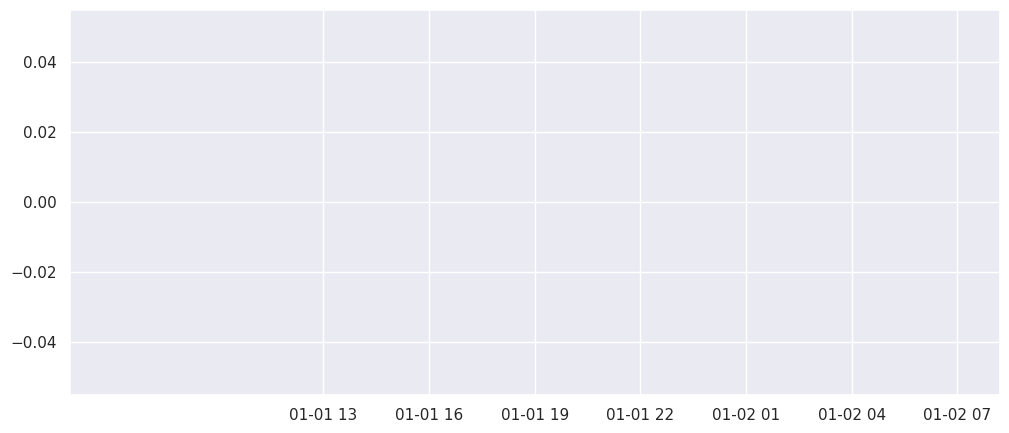

In [67]:
# print(da_clip)
one_point = full_ds_clip.isel(latitude=5, longitude=5)
one_point = one_point.sel(time=slice(datetime(2021, 2, 1, 0), datetime(2021, 3, 1, 0)))
print(one_point)

print(len(one_point['time']))

fig, ax = plt.subplots(figsize = (12, 5))
ax.plot(one_point['time'], 
     one_point['APCP_surface'])
plt.show()

In [412]:
print(f'Variable size: {da_clip['TMP_2maboveground'].nbytes/1e6:.2f} MB')

Variable size: 224.59 MB


In [422]:
da_clip['time']

<xarray.DataArray 'time' (time: 8784)> Size: 70kB
array(['2020-01-01T00:00:00.000000000', '2020-01-01T01:00:00.000000000',
       '2020-01-01T02:00:00.000000000', ..., '2020-12-31T21:00:00.000000000',
       '2020-12-31T22:00:00.000000000', '2020-12-31T23:00:00.000000000'],
      shape=(8784,), dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 70kB 2020-01-01 ... 2020-12-31T23:00:00
    spatial_ref  int64 8B 0
Attributes:
    long_name:                   verification time generated by wgrib2 functi...
    reference_date:              2020.01.01 00:00:00 UTC
    reference_time:              1577836800.0
    reference_time_description:  kind of product unclear, reference date is v...
    reference_time_type:         0
    time_step:                   0.0
    time_step_setting:           auto

In [454]:
da_april1 = da_clip.sel(time=slice(datetime.datetime(2020, 4, 1, 0), datetime.datetime(2020, 4, 13, 23)))
da_april1

<xarray.Dataset> Size: 64MB
Dimensions:              (latitude: 47, longitude: 68, time: 312)
Coordinates:
  * latitude             (latitude) float64 376B 43.81 43.82 ... 44.18 44.19
  * longitude            (longitude) float64 544B -115.9 -115.9 ... -115.4
  * time                 (time) datetime64[ns] 2kB 2020-04-01 ... 2020-04-13T...
    spatial_ref          int64 8B 0
Data variables:
    APCP_surface         (time, latitude, longitude) float64 8MB dask.array<chunksize=(120, 47, 68), meta=np.ndarray>
    DLWRF_surface        (time, latitude, longitude) float64 8MB dask.array<chunksize=(120, 47, 68), meta=np.ndarray>
    DSWRF_surface        (time, latitude, longitude) float64 8MB dask.array<chunksize=(120, 47, 68), meta=np.ndarray>
    PRES_surface         (time, latitude, longitude) float64 8MB dask.array<chunksize=(120, 47, 68), meta=np.ndarray>
    SPFH_2maboveground   (time, latitude, longitude) float64 8MB dask.array<chunksize=(120, 47, 68), meta=np.ndarray>
    TMP_2maboveground    (time, latitude, longitude) float64 8MB dask.array<chunksize=(120, 47, 68), meta=np.ndarray>
    UGRD_10maboveground  (time, latitude, longitude) float64 8MB dask.array<chunksize=(120, 47, 68), meta=np.ndarray>
    VGRD_10maboveground  (time, latitude, longitude) float64 8MB dask.array<chunksize=(120, 47, 68), meta=np.ndarray>

In [456]:
print(f'Variable size for 13 days: {da_april1['TMP_2maboveground'].nbytes/1e6:.2f} MB')

Variable size for 13 days: 7.98 MB


In [438]:
print(CRS)

EPSG:26911


In [439]:
da_april1_geo = da_april1.rename(
            longitude="x",
            latitude="y"
        )

da_april1_geo = da_april1_geo.rio.set_spatial_dims(x_dim="x", y_dim="y")

# Assign correct HRRR CRS
da_april1_geo = da_april1_geo.rio.write_crs('EPSG:4326')
print(da_april1_geo)

da_april1_reproj = da_april1_geo.rio.reproject(CRS, resolution=RES)

<xarray.Dataset> Size: 5MB
Dimensions:              (y: 47, x: 68, time: 24)
Coordinates:
  * y                    (y) float64 376B 43.81 43.82 43.82 ... 44.18 44.19
  * x                    (x) float64 544B -115.9 -115.9 -115.9 ... -115.4 -115.4
  * time                 (time) datetime64[ns] 192B 2020-04-01 ... 2020-04-01...
    spatial_ref          int64 8B 0
Data variables:
    APCP_surface         (time, y, x) float64 614kB dask.array<chunksize=(24, 47, 68), meta=np.ndarray>
    DLWRF_surface        (time, y, x) float64 614kB dask.array<chunksize=(24, 47, 68), meta=np.ndarray>
    DSWRF_surface        (time, y, x) float64 614kB dask.array<chunksize=(24, 47, 68), meta=np.ndarray>
    PRES_surface         (time, y, x) float64 614kB dask.array<chunksize=(24, 47, 68), meta=np.ndarray>
    SPFH_2maboveground   (time, y, x) float64 614kB dask.array<chunksize=(24, 47, 68), meta=np.ndarray>
    TMP_2maboveground    (time, y, x) float64 614kB dask.array<chunksize=(24, 47, 68), meta=np.ndarr

took 3 sec to plot a single day/hour 

also took 3 sec to plot the mean temp over 1 day 

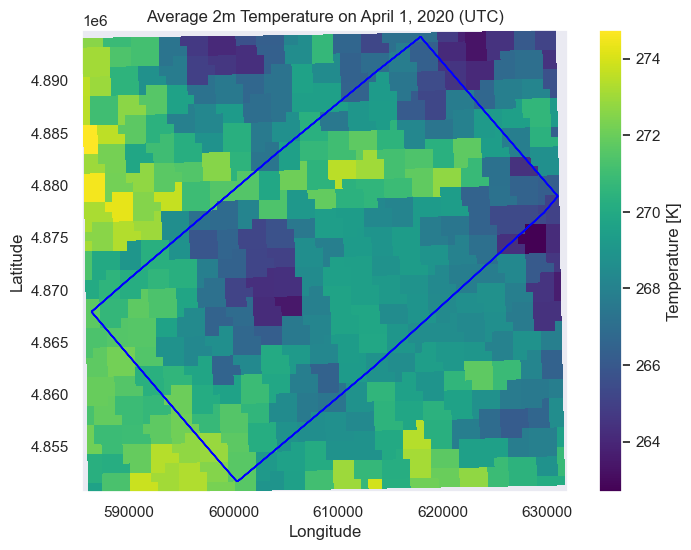

In [442]:
# plt.imshow(np.mean(da_april1['TMP_2maboveground'].values, axis=0), origin='lower')

fig, ax = plt.subplots(figsize=(8, 6))
im = da_april1_reproj['TMP_2maboveground'].mean(dim='time').plot(ax=ax, cmap='viridis')
outline_utm.boundary.plot(ax=ax, edgecolor='blue', linewidth=1)
ax.set_title('Average 2m Temperature on April 1, 2020 (UTC)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
# fig.colorbar(im, ax=ax, label='Temperature (K)')
plt.show()